##**Problem Statement**

**Dataset Link**: https://drive.google.com/file/d/1WeM6XKBtdSP2ytWYBpRfl8-VzBn19voH/view?usp=sharing


**Importing the libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Configurational Library**

In [ ]:
from warnings import filterwarnings
filterwarnings('ignore')

**Load the data**

In [ ]:
raw_data = pd.read_csv('/content/scrap price.csv')
raw_data.head()

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


**Inisght**
* Price (Target Column)
* rest are independent feature

**Shape Analysis**

In [ ]:
a = raw_data.shape
print(f'Rows: {a[0]} and columns: {a[1]}')

Rows: 205 and columns: 26


**Column analysis**

In [ ]:
raw_data.columns

Index(['ID', 'symboling', 'name', 'fueltypes', 'aspiration', 'doornumbers',
       'carbody', 'drivewheels', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='object')

**info of the data**

In [ ]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   name              205 non-null    object 
 3   fueltypes         205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumbers       205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheels       205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

**Statstics of Data**

In [ ]:
raw_data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,205.0,103.000000,59.322565,1.00,52.00,103.00,154.00,205.00
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00
wheelbase,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
carlength,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
carwidth,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
carheight,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
curbweight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
enginesize,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00
boreratio,205.0,3.329756,0.270844,2.54,3.15,3.31,3.58,3.94
stroke,205.0,3.255415,0.313597,2.07,3.11,3.29,3.41,4.17


**Insights**
* We have Price Variation
* Engine and horse power also variations can be used to predict price strongly
* ID column does not make sense as we have index

In [ ]:
raw_data.isnull().sum().sum()

np.int64(0)

In [ ]:
raw_data.describe(include = 'object').T

,count,unique,top,freq
name,205,147,peugeot 504,6
fueltypes,205,2,gas,185
aspiration,205,2,std,168
doornumbers,205,2,four,115
carbody,205,5,sedan,96
drivewheels,205,3,fwd,120
enginelocation,205,2,front,202
enginetype,205,7,ohc,148
cylindernumber,205,7,four,159
fuelsystem,205,8,mpfi,94


**Insights**
* Most cat runs on Gas
* Standard car are more than any turbo
* Sedans are most common


###**Data Cleaning**

In [ ]:
data = raw_data.drop('ID',axis = 1)
data.head()

,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


**duplicate Values**

In [ ]:
data.duplicated().sum()

np.int64(0)

**Let's Check all the unique Names**

In [ ]:
data.name.unique()

array(['alfa-romero giulia', 'alfa-romero stelvio',
       'alfa-romero Quadrifoglio', 'audi 100 ls', 'audi 100ls',
       'audi fox', 'audi 5000', 'audi 4000', 'audi 5000s (diesel)',
       'bmw 320i', 'bmw x1', 'bmw x3', 'bmw z4', 'bmw x4', 'bmw x5',
       'chevrolet impala', 'chevrolet monte carlo', 'chevrolet vega 2300',
       'dodge rampage', 'dodge challenger se', 'dodge d200',
       'dodge monaco (sw)', 'dodge colt hardtop', 'dodge colt (sw)',
       'dodge coronet custom', 'dodge dart custom',
       'dodge coronet custom (sw)', 'honda civic', 'honda civic cvcc',
       'honda accord cvcc', 'honda accord lx', 'honda civic 1500 gl',
       'honda accord', 'honda civic 1300', 'honda prelude',
       'honda civic (auto)', 'isuzu MU-X', 'isuzu D-Max ',
       'isuzu D-Max V-Cross', 'jaguar xj', 'jaguar xf', 'jaguar xk',
       'maxda rx3', 'maxda glc deluxe', 'mazda rx2 coupe', 'mazda rx-4',
       'mazda glc deluxe', 'mazda 626', 'mazda glc', 'mazda rx-7 gs',
       'mazda glc 

**Feature Engineering based on Brand Names**

We will extract only the brand name from the full car name.

Example: `'audi 4000'` --> `audi`
* Full Names appear very few times, so the model cannot learn from them
* By using just the brand name gives us repeated values, which help the model to learn how different brands affect the price

In [ ]:
# x = 'Aryan Raj Deloit'
# x.split(' ')[0]
car_name = data['name'].apply(lambda x : x.split(' ')[0])

In [ ]:
data.head()

,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
data.insert(3, 'car_name',car_name)
data.head()

,symboling,name,fueltypes,car_name,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,alfa-romero,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero stelvio,gas,alfa-romero,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero Quadrifoglio,gas,alfa-romero,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi 100 ls,gas,audi,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi 100ls,gas,audi,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
data.drop(['name'], axis= 1, inplace = True)
data

,symboling,fueltypes,car_name,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,gas,alfa-romero,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,gas,alfa-romero,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,gas,alfa-romero,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,gas,audi,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,gas,audi,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,gas,volvo,std,four,sedan,rwd,front,109.1,188.8,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,-1,gas,volvo,turbo,four,sedan,rwd,front,109.1,188.8,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,-1,gas,volvo,std,four,sedan,rwd,front,109.1,188.8,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,-1,diesel,volvo,turbo,four,sedan,rwd,front,109.1,188.8,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


**Let's Check Now**

In [ ]:
data['car_name'].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'Nissan', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

**Let's correct spelling mistakes in brand names**

Example: `maxda` ---> `mazda`
* Computers treat different spellings as different brand
* We wil merges the same company into one, help my model to learn accurate patterns

In [ ]:
data['car_name'] = data['car_name'].replace({'maxda': 'mazda', 'Nissan': 'nissan', 'porcshce':
                                             'porsche', 'toyouta': 'toyota', 'vokswagen': 'volkswagen','vw': 'volkswagen' })

In [ ]:
data.car_name.unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'buick', 'mercury', 'mitsubishi',
       'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab',
       'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

**Let's Visualize outlier**

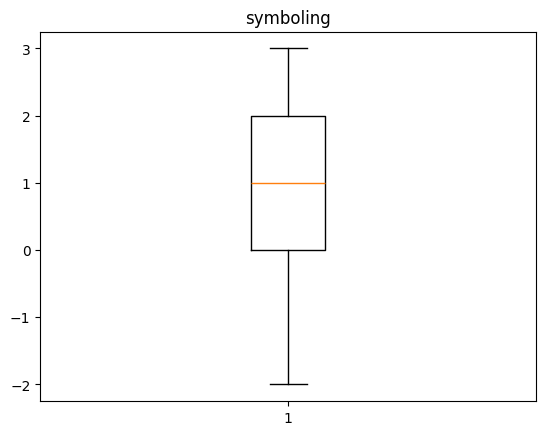

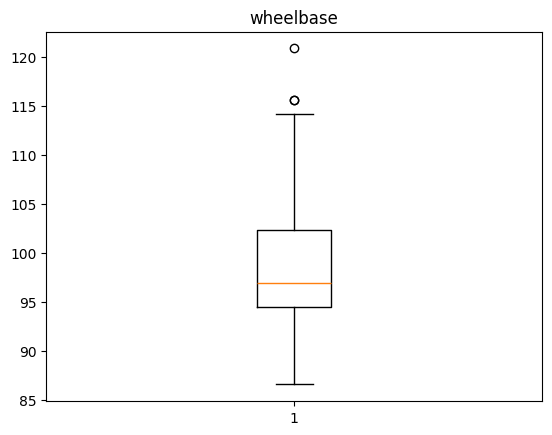

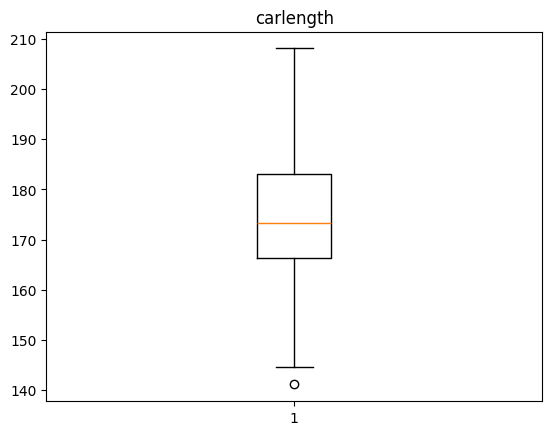

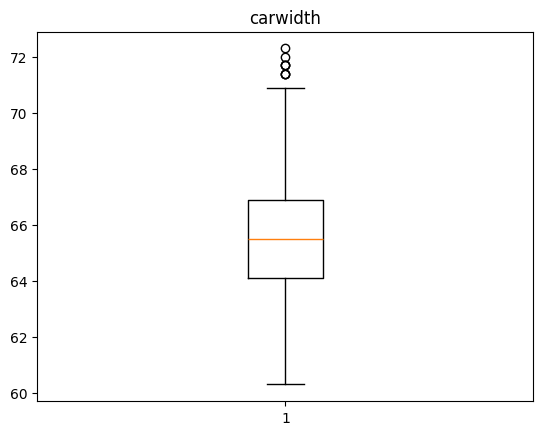

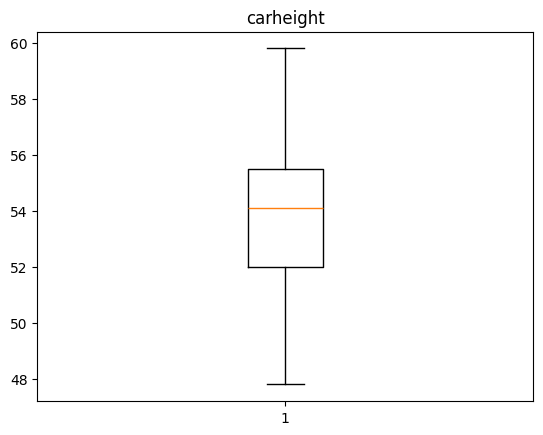

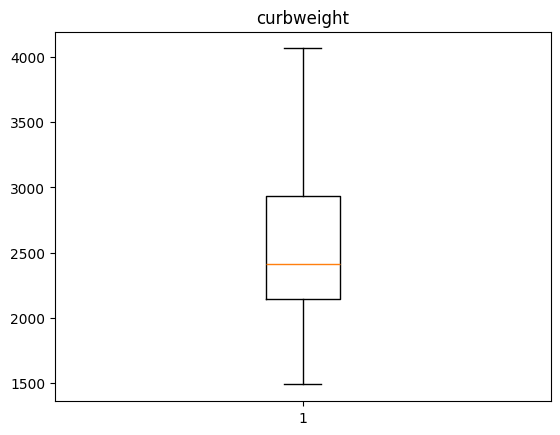

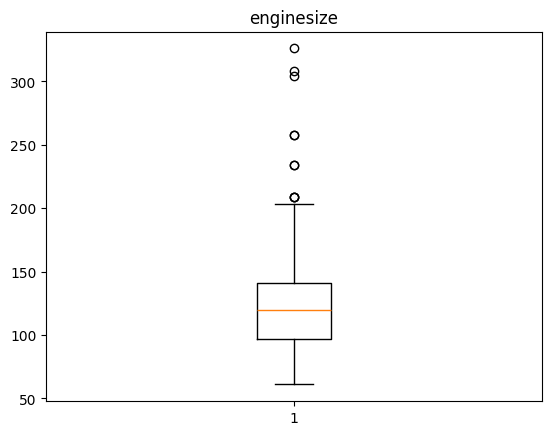

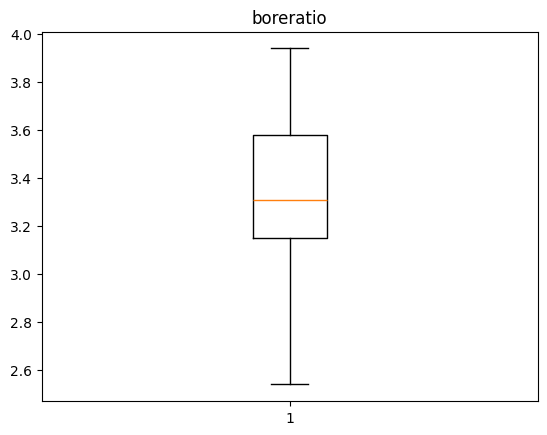

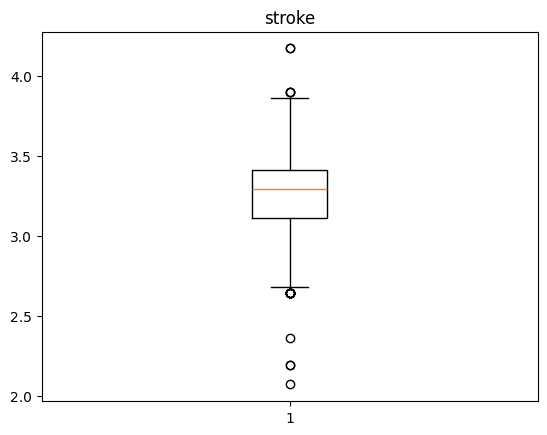

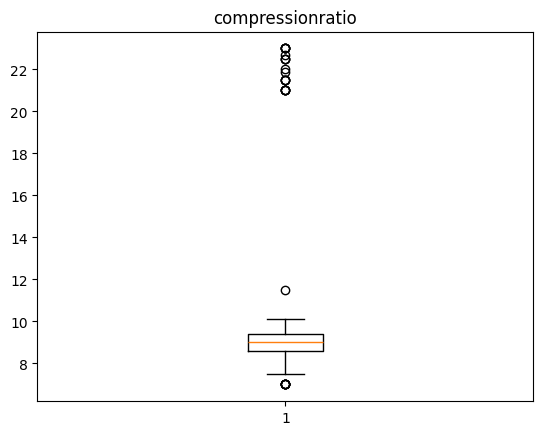

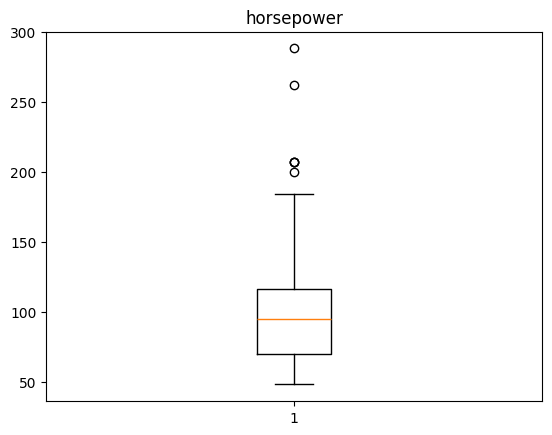

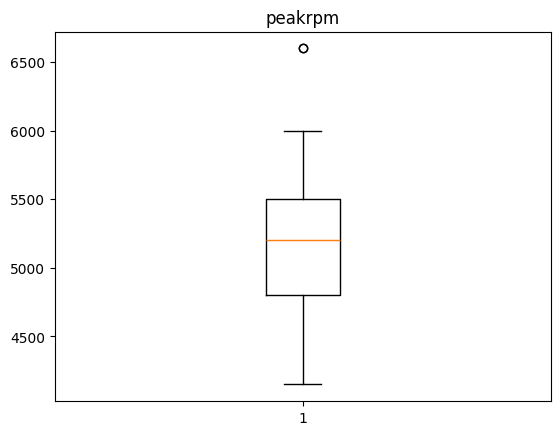

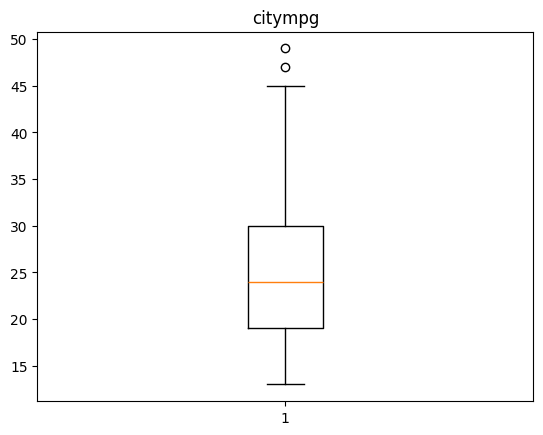

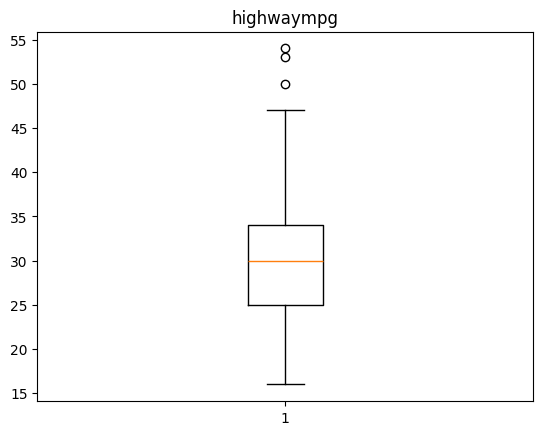

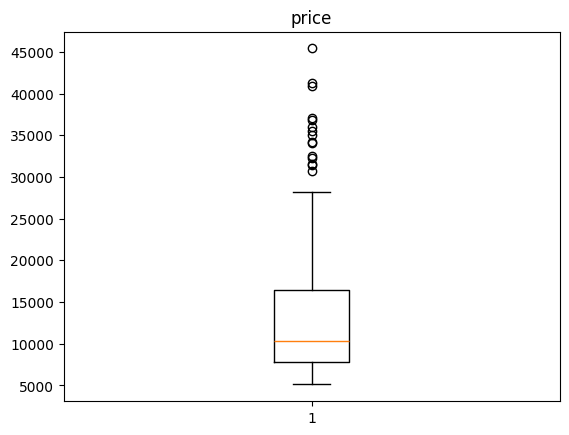

In [ ]:
for i in data.columns:
  if data[i].dtype != 'object':
    plt.boxplot(data[i])
    plt.title(i)
    plt.show()

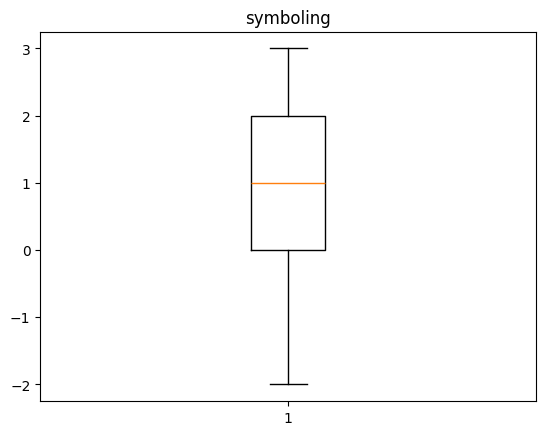

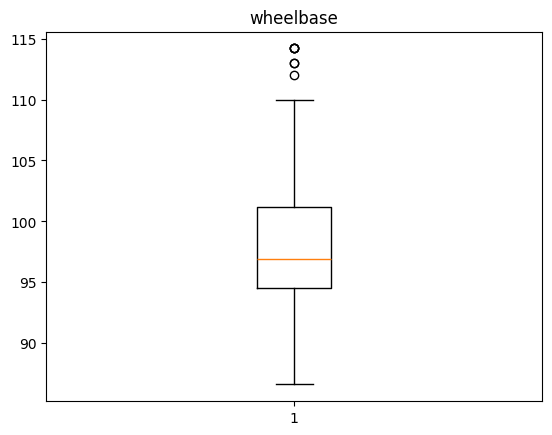

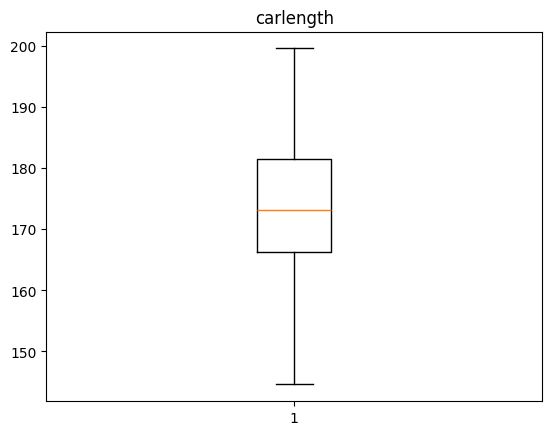

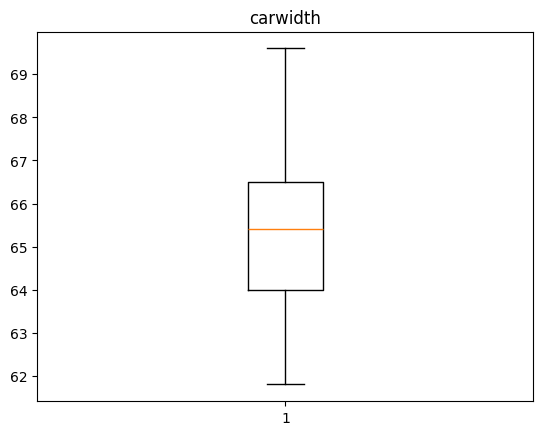

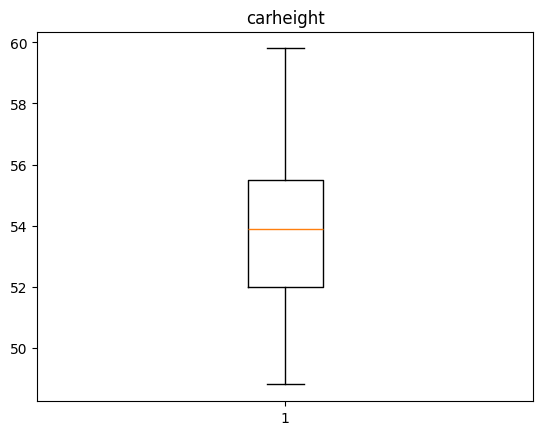

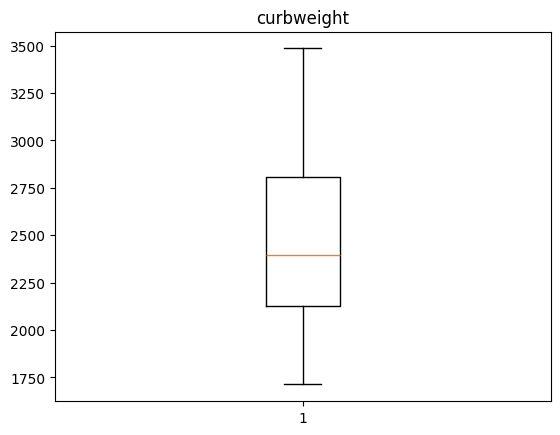

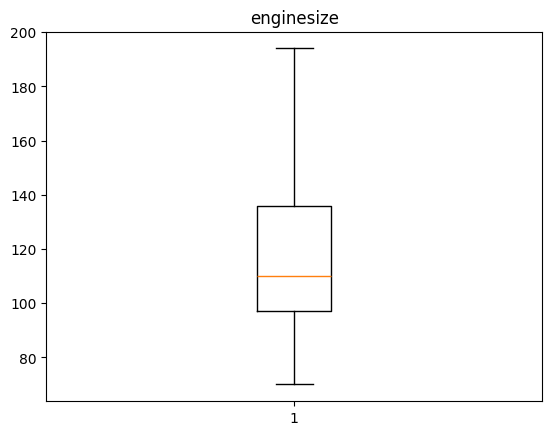

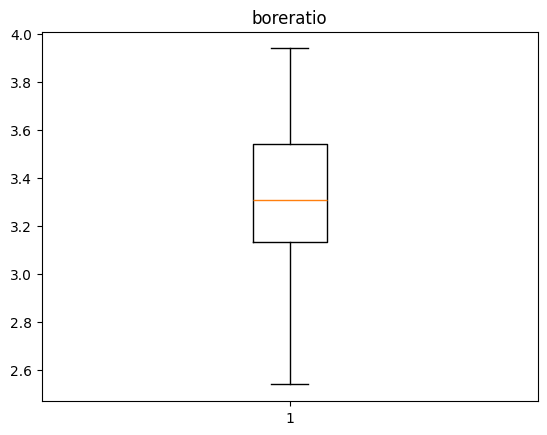

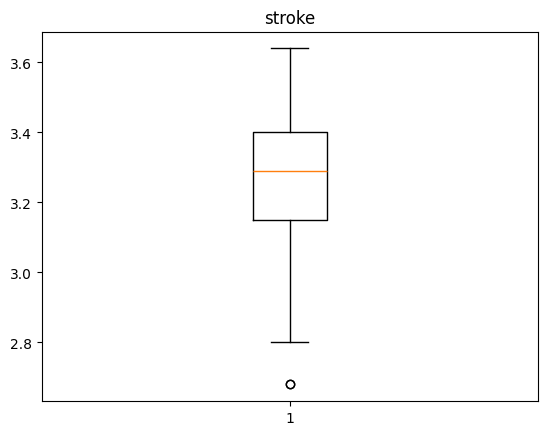

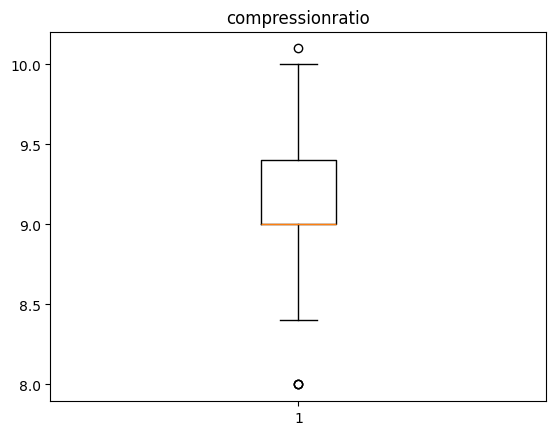

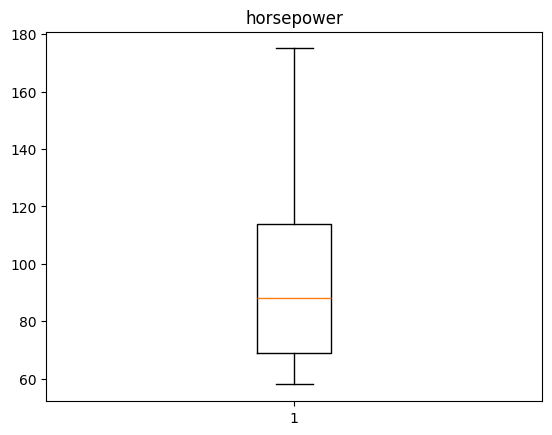

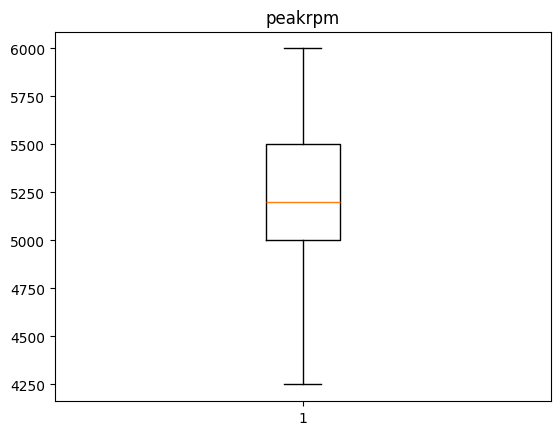

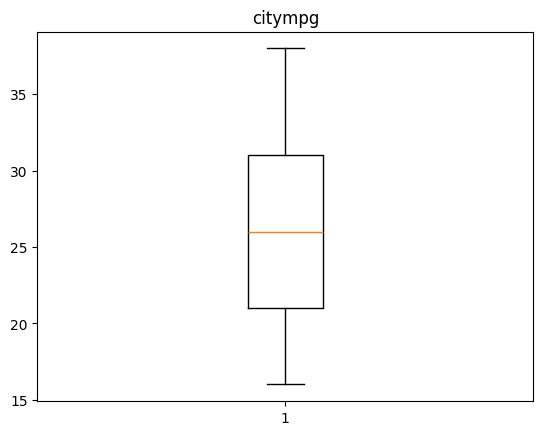

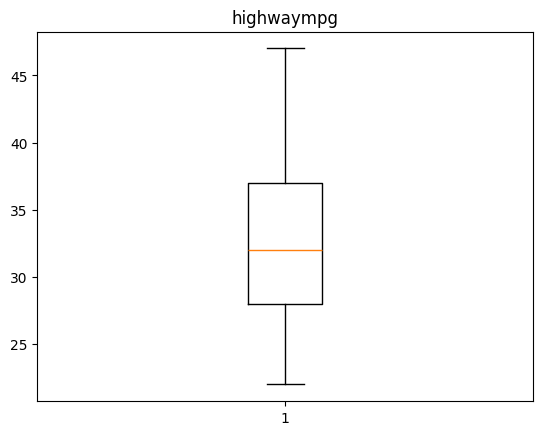

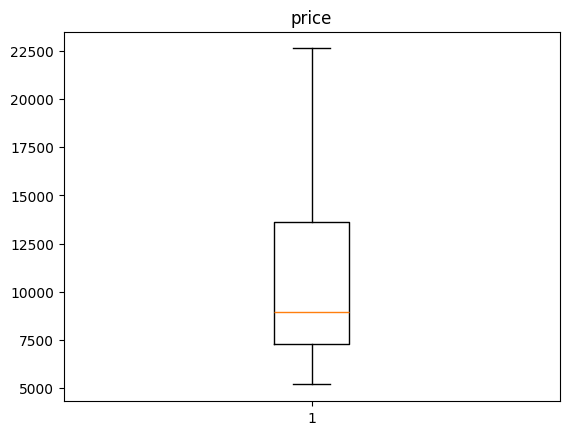

In [ ]:
for i in data.columns:
  if data[i].dtype != 'object':
    Q1 = data[i].quantile(0.25)
    Q3 = data[i].quantile(0.75)
    IQR = Q3 - Q1

    upperFence = Q3 + 1.5*IQR
    lowerFence = Q1 - 1.5*IQR

    data = data[(data[i]<=upperFence) & (data[i]>=lowerFence)]

    plt.boxplot(data[i])
    plt.title(i)
    plt.show()

**Let's Find the Correlation**

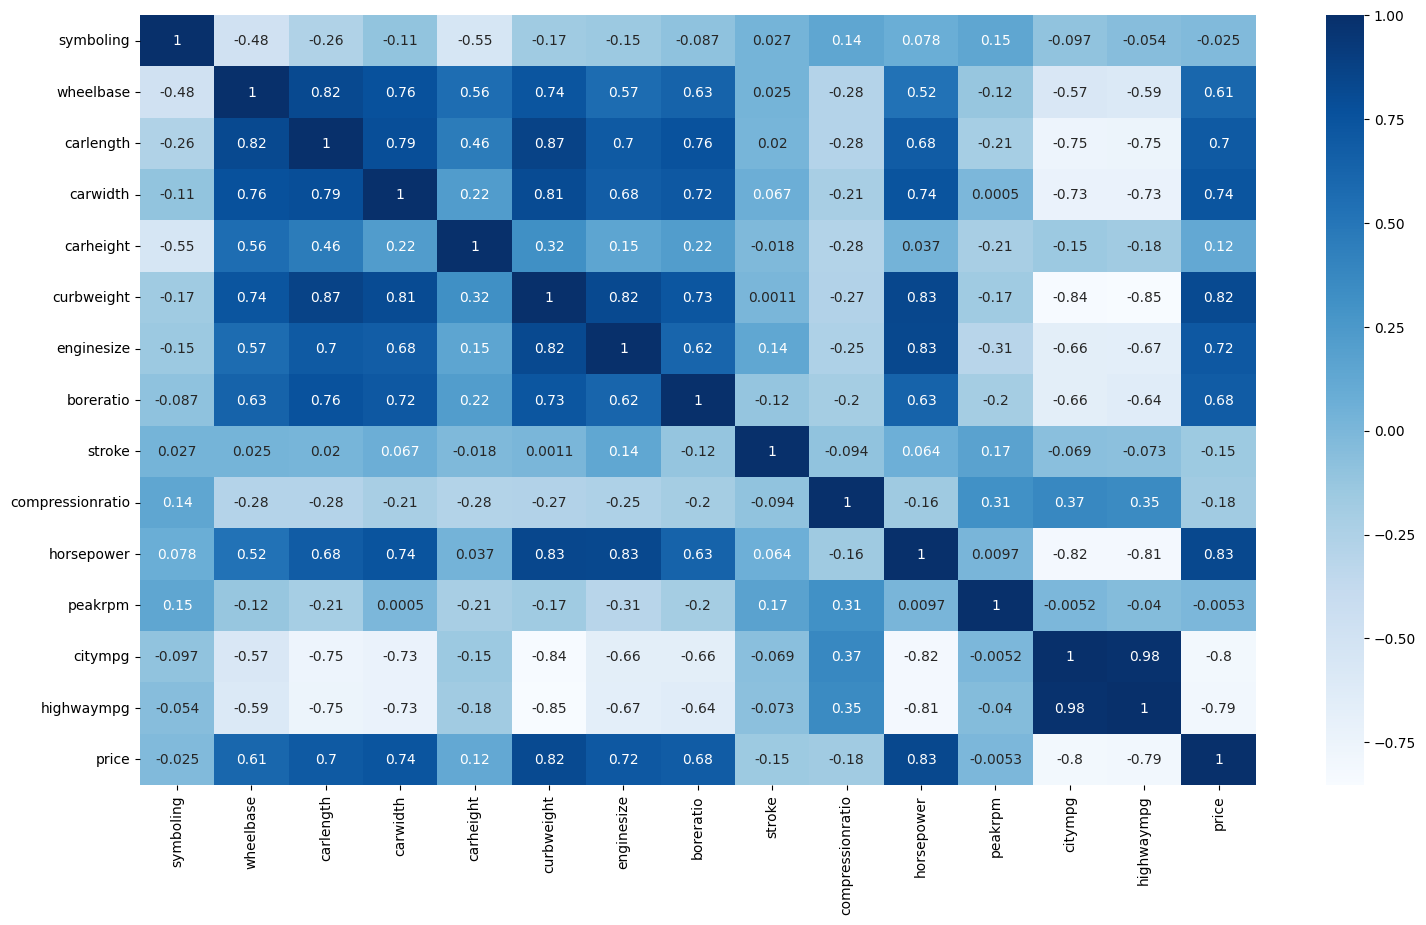

In [ ]:
plt.figure(figsize = (18,10))
sns.heatmap(data.corr(numeric_only=True), annot = True, cmap='Blues')
plt.show()

**Insight**

Let's remove features that give same information (multicolinearity)

* Car Size : curbweight (keep) -- Remove wheelbase, length and width
* Fuel efficiency: citympg and highwaympg are almost same (citympg)

In [ ]:
data.columns

Index(['symboling', 'fueltypes', 'car_name', 'aspiration', 'doornumbers',
       'carbody', 'drivewheels', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='object')

In [ ]:
data.drop(columns=['wheelbase', 'carlength',
       'carwidth','highwaympg'] ,axis = 1, inplace = True)

In [ ]:
data.columns

Index(['symboling', 'fueltypes', 'car_name', 'aspiration', 'doornumbers',
       'carbody', 'drivewheels', 'enginelocation', 'carheight', 'curbweight',
       'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio',
       'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg',
       'price'],
      dtype='object')

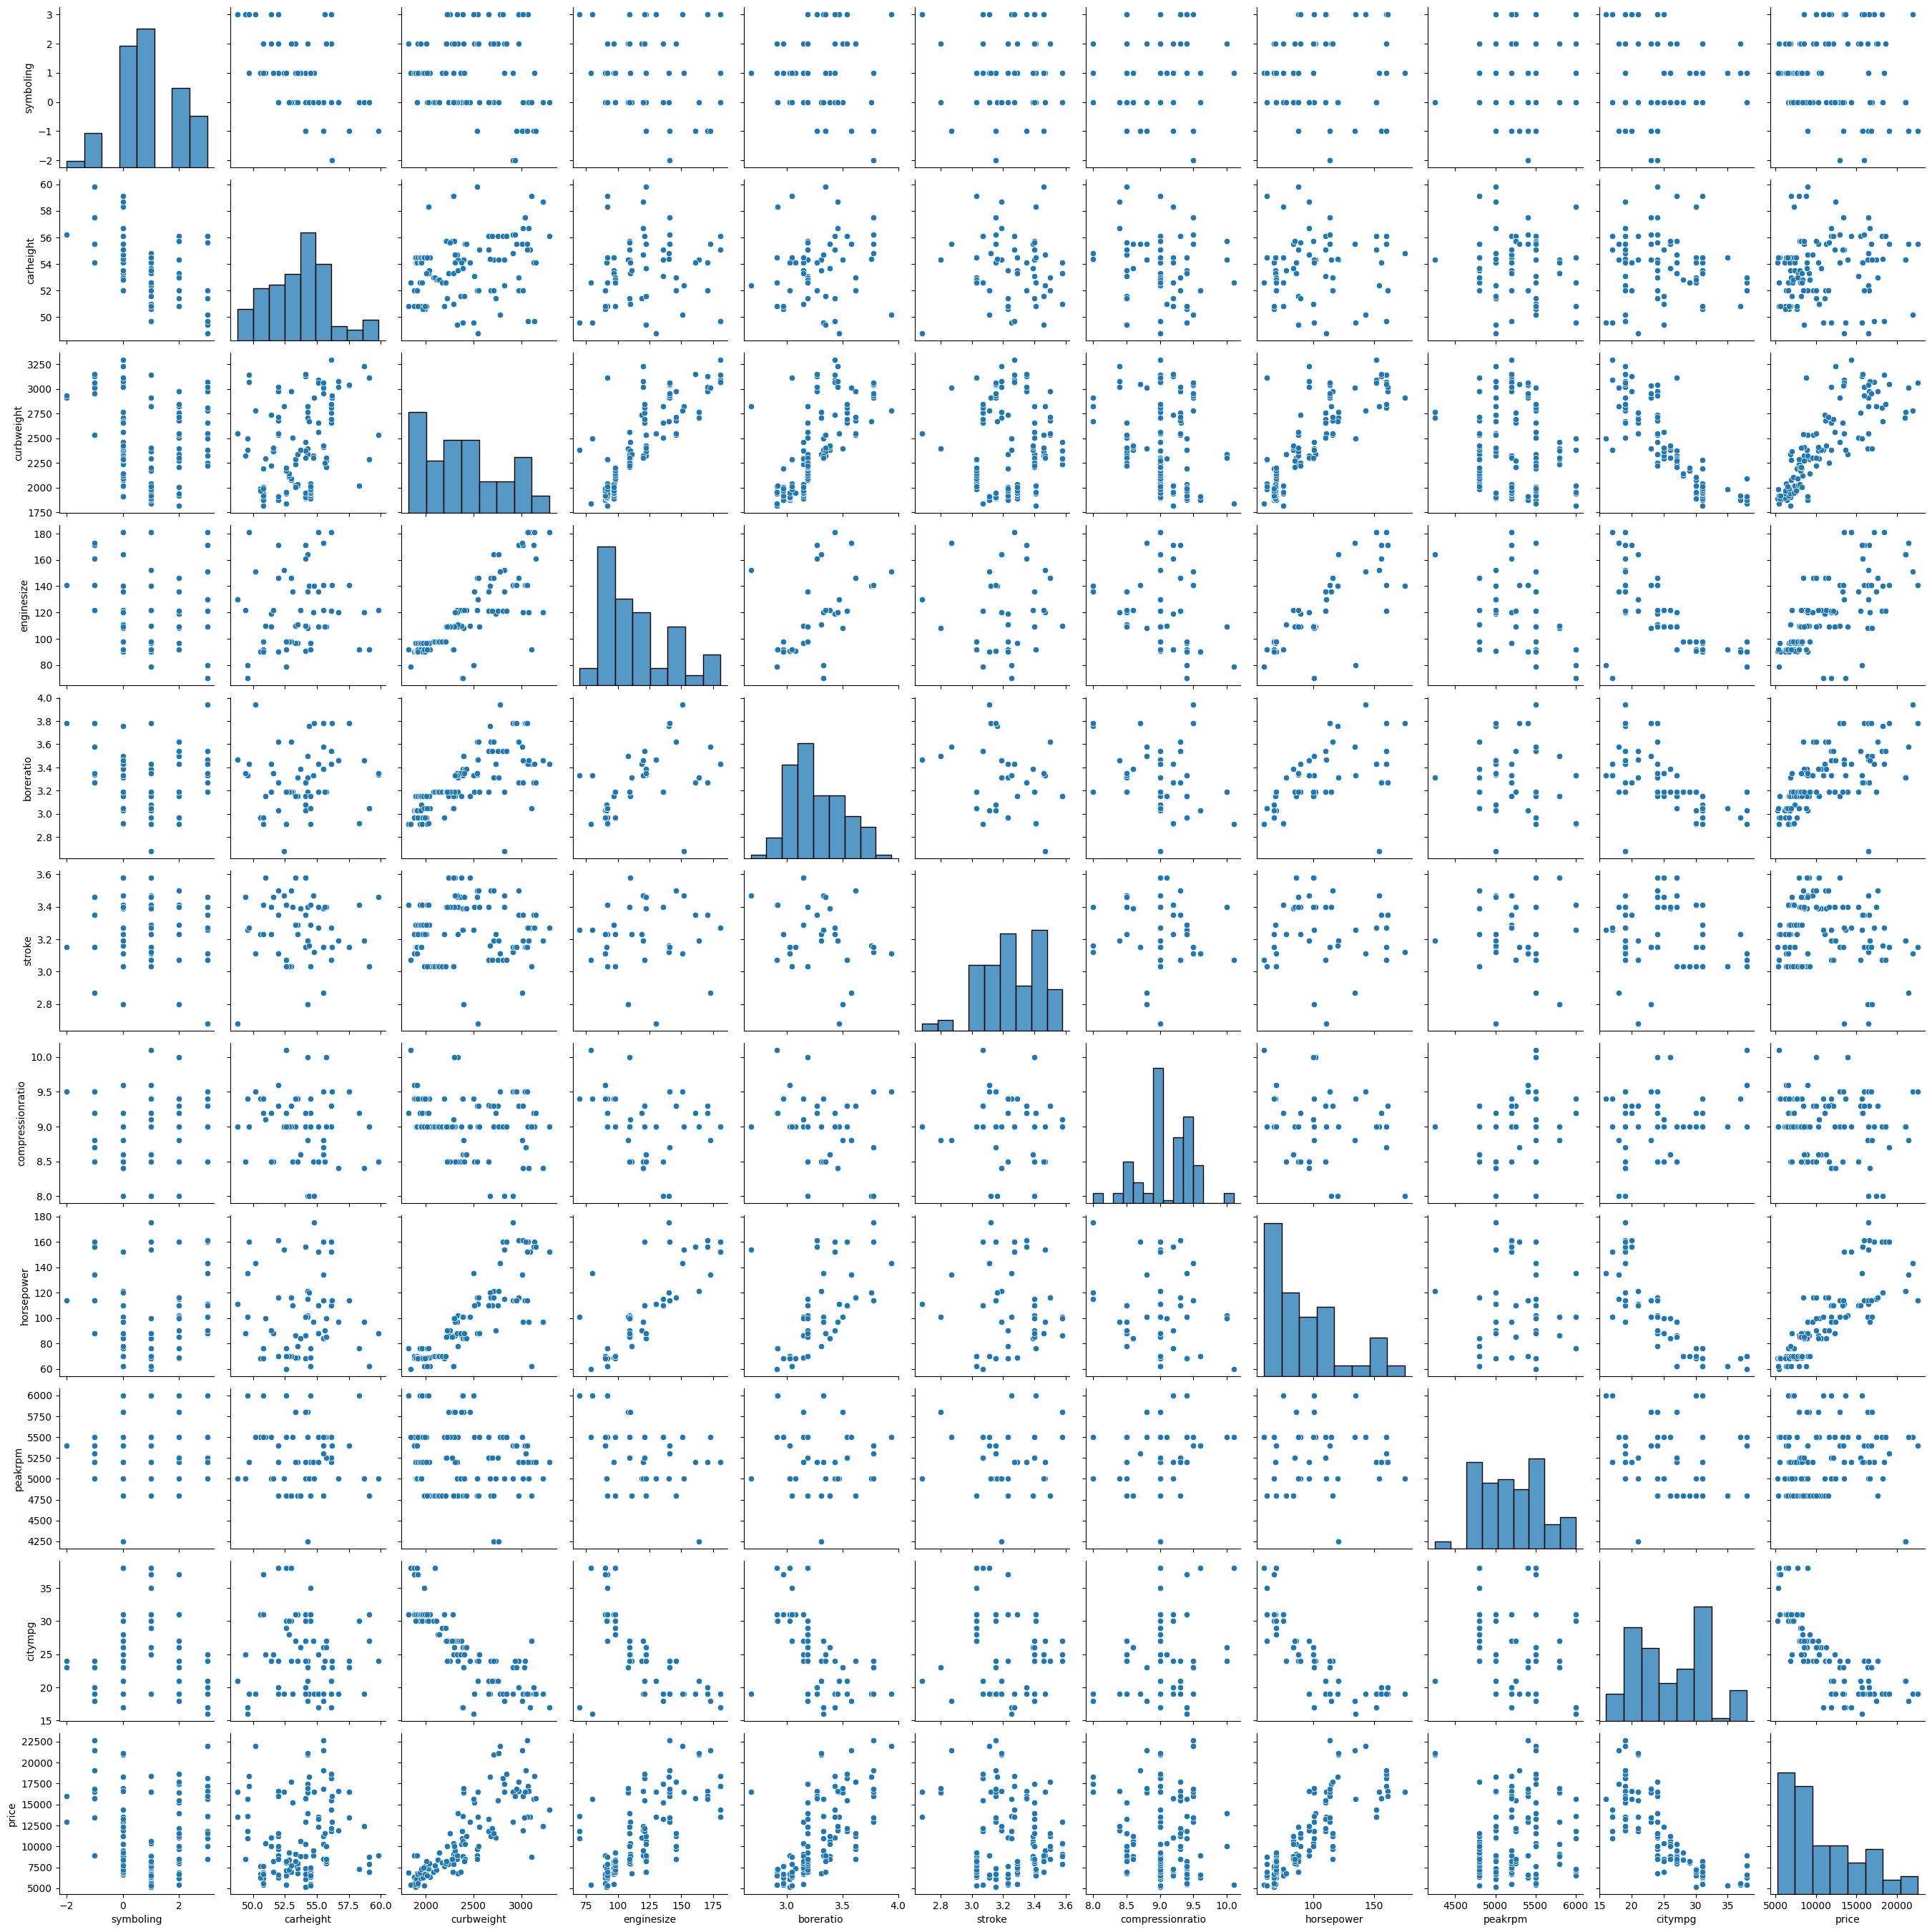

In [ ]:
sns.pairplot(data)
plt.show()

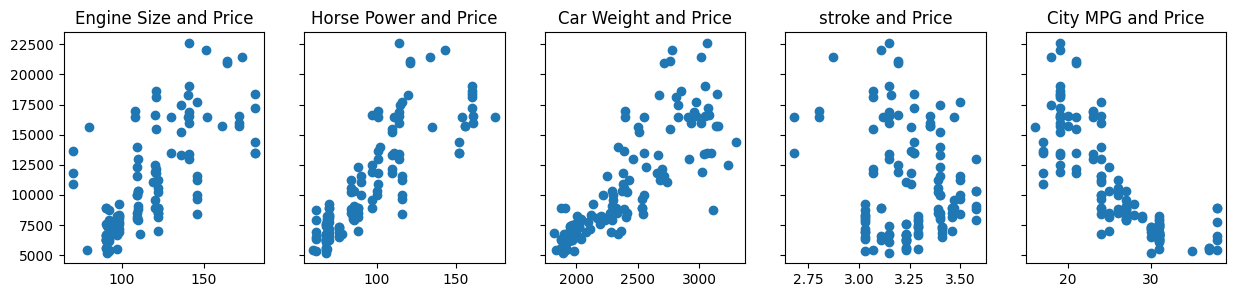

In [ ]:
# engisze, hp, weightm, milage, stroke
fig, (ax1,ax2,ax3,ax4,ax5) = plt.subplots(1,5, sharey=True, figsize = (15,3))
ax1.scatter(data['enginesize'],data['price'])
ax1.set_title('Engine Size and Price')

ax2.scatter(data['horsepower'],data['price'])
ax2.set_title('Horse Power and Price')

ax3.scatter(data['curbweight'],data['price'])
ax3.set_title('Car Weight and Price')

ax4.scatter(data['stroke'],data['price'])
ax4.set_title('stroke and Price')

ax5.scatter(data['citympg'],data['price'])
ax5.set_title('City MPG and Price')

plt.show()


**Insights**
* As engine Size increase ---> Price Increase
* As Horse Power Incerase ---> Price Increase
* city milage inversely effecting price

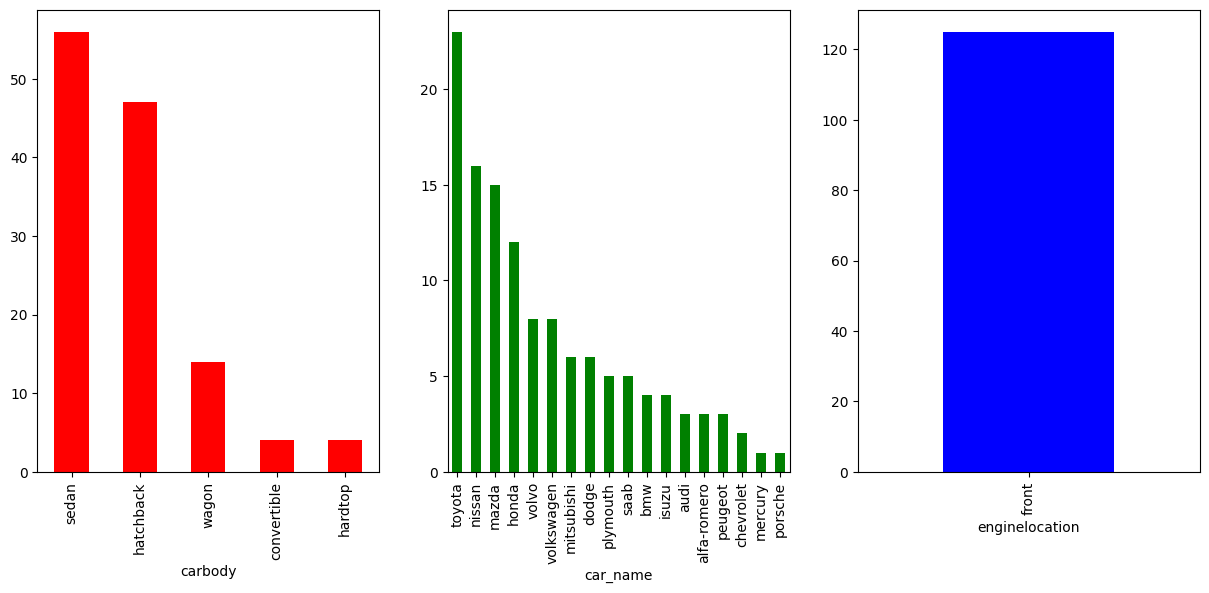

In [ ]:
plt.figure(figsize = (15,6))
plt.subplot(1,3,1)
data.carbody.value_counts().plot(kind = 'bar',color = 'r')
plt.subplot(1,3,2)
data.car_name.value_counts().plot(kind = 'bar',color = 'g')
plt.subplot(1,3,3)
data.enginelocation.value_counts().plot(kind = 'bar',color = 'b')
plt.show()

**Insights**

**Car Body**
* Sedan ins the most common followed by Hatchback
* Convertible and hardtop are very rare

**Brand Distribution**
* Toyota is the most frequent brand, followed by nissan and mazda
* Luxury brands lke BMW, Audi, Porshe appears very few times

**Engine Location**
* Almost all cars have front engines
* Rear engines are none (after cleaning data)


**Data Pre processing**

Our dependent value (y) are price

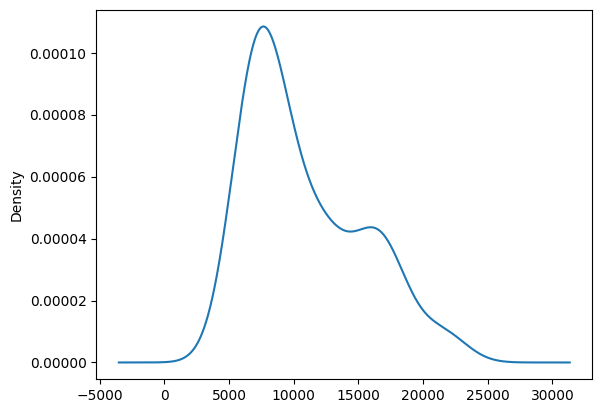

In [ ]:
data.price.plot.density()
plt.show()

In [ ]:
data.price.skew()

np.float64(0.8080096690712006)

**Let's perform Log transformation**

In [ ]:
data.price

,price
0,13495.0
1,16500.0
2,16500.0
3,13950.0
4,17450.0
...,...
197,16515.0
200,16845.0
201,19045.0
202,21485.0


In [ ]:
log_price = np.log(data['price'])
log_price

,price
0,9.510075
1,9.711116
2,9.711116
3,9.543235
4,9.767095
...,...
197,9.712024
200,9.731809
201,9.854560
202,9.975110


In [ ]:
data['log_price'] = log_price
data.head()

,symboling,fueltypes,car_name,aspiration,doornumbers,carbody,drivewheels,enginelocation,carheight,curbweight,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,price,log_price
0,3,gas,alfa-romero,std,two,convertible,rwd,front,48.8,2548,...,130,mpfi,3.47,2.68,9.0,111,5000,21,13495.0,9.510075
1,3,gas,alfa-romero,std,two,convertible,rwd,front,48.8,2548,...,130,mpfi,3.47,2.68,9.0,111,5000,21,16500.0,9.711116
2,1,gas,alfa-romero,std,two,hatchback,rwd,front,52.4,2823,...,152,mpfi,2.68,3.47,9.0,154,5000,19,16500.0,9.711116
3,2,gas,audi,std,four,sedan,fwd,front,54.3,2337,...,109,mpfi,3.19,3.40,10.0,102,5500,24,13950.0,9.543235
4,2,gas,audi,std,four,sedan,4wd,front,54.3,2824,...,136,mpfi,3.19,3.40,8.0,115,5500,18,17450.0,9.767095


In [ ]:
data_normal = data.drop(['price'],axis=1)
data_normal.head()

,symboling,fueltypes,car_name,aspiration,doornumbers,carbody,drivewheels,enginelocation,carheight,curbweight,...,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,log_price
0,3,gas,alfa-romero,std,two,convertible,rwd,front,48.8,2548,...,four,130,mpfi,3.47,2.68,9.0,111,5000,21,9.510075
1,3,gas,alfa-romero,std,two,convertible,rwd,front,48.8,2548,...,four,130,mpfi,3.47,2.68,9.0,111,5000,21,9.711116
2,1,gas,alfa-romero,std,two,hatchback,rwd,front,52.4,2823,...,six,152,mpfi,2.68,3.47,9.0,154,5000,19,9.711116
3,2,gas,audi,std,four,sedan,fwd,front,54.3,2337,...,four,109,mpfi,3.19,3.40,10.0,102,5500,24,9.543235
4,2,gas,audi,std,four,sedan,4wd,front,54.3,2824,...,five,136,mpfi,3.19,3.40,8.0,115,5500,18,9.767095


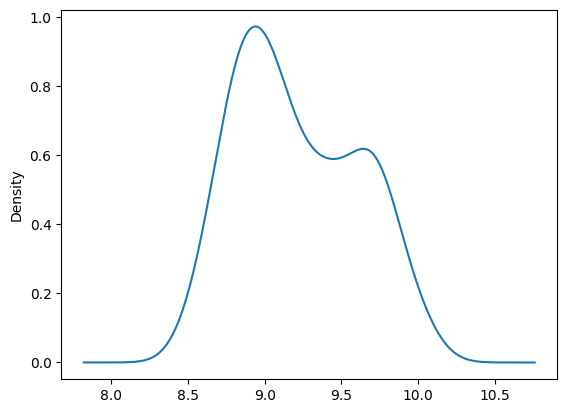

In [ ]:
data_normal.log_price.plot.density()
plt.show()

In [ ]:
data_normal.log_price.skew()

np.float64(0.31142697501305067)

**VIF (Variance Inflation factor)**
* It finds out the multicolinearity and remove the columns that are highly correlated

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
variables = data_normal.select_dtypes(include='number').copy()
variables.drop('log_price',axis = 1, inplace = True)

In [ ]:
variables.head()

,symboling,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg
0,3,48.8,2548,130,3.47,2.68,9.0,111,5000,21
1,3,48.8,2548,130,3.47,2.68,9.0,111,5000,21
2,1,52.4,2823,152,2.68,3.47,9.0,154,5000,19
3,2,54.3,2337,109,3.19,3.40,10.0,102,5500,24
4,2,54.3,2824,136,3.19,3.40,8.0,115,5500,18


In [ ]:
while True:
    vif = pd.DataFrame()
    vif["VIF"] = [variance_inflation_factor(variables.values, i)
                  for i in range(variables.shape[1])]
    vif["Features"] = variables.columns

    max_vif = vif["VIF"].max()

    if max_vif < 6:
        break


    drop_feature = vif.sort_values("VIF", ascending=False)["Features"].iloc[0]
    print("Dropping:", drop_feature, " | VIF:", max_vif)

    variables = variables.drop(columns=[drop_feature])

Dropping: compressionratio  | VIF: 767.9227067726754
Dropping: carheight  | VIF: 581.7384071476698
Dropping: stroke  | VIF: 299.3731865986223
Dropping: boreratio  | VIF: 277.1761550088302
Dropping: peakrpm  | VIF: 152.05512185571118
Dropping: curbweight  | VIF: 96.85955792765448
Dropping: enginesize  | VIF: 68.79104234346227


In [ ]:
print(vif)

        VIF    Features
0  1.624123   symboling
1  4.788608  horsepower
2  4.605280     citympg


In [ ]:
data_multi = data_normal[
    list(vif['Features']) +
    list(data_normal.select_dtypes(include='object').columns)
]
data_multi['log_price'] = data['log_price']
data_multi.head()

,symboling,horsepower,citympg,fueltypes,car_name,aspiration,doornumbers,carbody,drivewheels,enginelocation,enginetype,cylindernumber,fuelsystem,log_price
0,3,111,21,gas,alfa-romero,std,two,convertible,rwd,front,dohc,four,mpfi,9.510075
1,3,111,21,gas,alfa-romero,std,two,convertible,rwd,front,dohc,four,mpfi,9.711116
2,1,154,19,gas,alfa-romero,std,two,hatchback,rwd,front,ohcv,six,mpfi,9.711116
3,2,102,24,gas,audi,std,four,sedan,fwd,front,ohc,four,mpfi,9.543235
4,2,115,18,gas,audi,std,four,sedan,4wd,front,ohc,five,mpfi,9.767095


**One Hot encoding**

In [ ]:
data_dummies = pd.get_dummies(data_multi, drop_first=True)
data_dummies.head()

,symboling,horsepower,citympg,log_price,car_name_audi,car_name_bmw,car_name_chevrolet,car_name_dodge,car_name_honda,car_name_isuzu,...,enginetype_ohc,enginetype_ohcv,enginetype_rotor,cylindernumber_four,cylindernumber_six,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_mpfi,fuelsystem_spfi
0,3,111,21,9.510075,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
1,3,111,21,9.711116,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,1,154,19,9.711116,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,True,False
3,2,102,24,9.543235,True,False,False,False,False,False,...,True,False,False,True,False,False,False,False,True,False
4,2,115,18,9.767095,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False


In [ ]:
import statsmodels.api as sm

In [ ]:
y = data_dummies['log_price']
x1 = data_dummies.drop(['log_price'],axis = 1)
x = sm.add_constant(pd.DataFrame(x1))

In [ ]:
x

,const,symboling,horsepower,citympg,car_name_audi,car_name_bmw,car_name_chevrolet,car_name_dodge,car_name_honda,car_name_isuzu,...,enginetype_ohc,enginetype_ohcv,enginetype_rotor,cylindernumber_four,cylindernumber_six,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_mpfi,fuelsystem_spfi
0,1.0,3,111,21,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
1,1.0,3,111,21,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,1.0,1,154,19,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,True,False
3,1.0,2,102,24,True,False,False,False,False,False,...,True,False,False,True,False,False,False,False,True,False
4,1.0,2,115,18,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,1.0,-1,114,24,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,True,False
200,1.0,-1,114,23,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,True,False
201,1.0,-1,160,19,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,True,False
202,1.0,-1,134,18,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,True,False


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
input_scaled = scaler.fit_transform(x)
input_scaled

array([[ 0.        ,  1.74197127,  0.53490949, ..., -0.15681251,
         1.14665375, -0.08980265],
       [ 0.        ,  1.74197127,  0.53490949, ..., -0.15681251,
         1.14665375, -0.08980265],
       [ 0.        ,  0.05401461,  1.99585387, ..., -0.15681251,
         1.14665375, -0.08980265],
       ...,
       [ 0.        , -1.63394204,  2.19970657, ..., -0.15681251,
         1.14665375, -0.08980265],
       [ 0.        , -1.63394204,  1.31634486, ..., -0.15681251,
         1.14665375, -0.08980265],
       [ 0.        , -1.63394204,  0.63683585, ..., -0.15681251,
         1.14665375, -0.08980265]])

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(input_scaled, y , test_size = 0.2, random_state=42)

In [ ]:
x_train.shape, x_test.shape

((100, 40), (25, 40))

In [ ]:
results = sm.OLS(y_train,x_train).fit()
# To get the summary of the model
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     23.27
Date:                Sat, 31 Jan 2026   Prob (F-statistic):           4.56e-25
Time:                        07:29:52   Log-Likelihood:                 81.975
No. Observations:                 100   AIC:                            -91.95
Df Residuals:                      64   BIC:                             1.836
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.859e-15   2.31e-17    340.278      0.000    7.81e-15    7.91e-15
x1            -0.0153      0.033     -0.467      0.642      -0.081       0.050
x2             0.1798      0.064      2.799      0.007       0.051       0.308
x3            -0.0592      0.041     -1.433      0.157      -0.142       0.023
x4             0.0233      0.032      0.719      0.475      -0.041       0.088
x5             0.0452      0.031      1.481      0.143      -0.016       0.106
x6           -65.5674      0.100   -653.662      0.000     -65.768     -65.367
x7            -0.0336      0.030     -1.112      0.270      -0.094       0.027
x8             0.0245      0.054      0.455      0.651      -0.083       0.132
x9            -0.0234      0.028     -0.831      0.409      -0.080       0.033
x10           -0.0151      0.046     -0.330      0.742      -0.106       0.076
x11           -0.0318      0.023     -1.392      0.169      -0.077       0.014
x12           -0.0429      0.032     -1.348      0.182      -0.107       0.021
x13           -0.0121      0.044     -0.276      0.784      -0.099       0.075
x14            0.0087      0.013      0.667      0.507      -0.017       0.035
x15           -0.0321      0.033     -0.983      0.329      -0.097       0.033
x16            0.0261      0.020      1.327      0.189      -0.013       0.065
x17            0.0153      0.037      0.414      0.680      -0.058       0.089
x18           -0.0504      0.049     -1.023      0.310      -0.149       0.048
x19           -0.0386      0.043     -0.896      0.374      -0.125       0.047
x20            0.0063      0.042      0.150      0.881      -0.077       0.090
x21            0.0275      0.021      1.297      0.199      -0.015       0.070
x22           -0.0283      0.026     -1.081      0.284      -0.081       0.024
x23           -0.0816      0.020     -4.000      0.000      -0.122      -0.041
x24           -0.1715      0.051     -3.376      0.001      -0.273      -0.070
x25           -0.1762      0.056     -3.143      0.003      -0.288      -0.064
x26           -0.1152      0.038     -3.006      0.004      -0.192      -0.039
x27           -0.0564      0.072     -0.786      0.435      -0.200       0.087
x28            0.0043      0.077      0.056      0.956      -0.149       0.158
x29            0.0087      0.013      0.667      0.507      -0.017       0.035
x30            0.0459      0.045      1.022      0.310      -0.044       0.136
x31           -0.0143      0.024     -0.601      0.550      -0.062       0.033
x32           -9.2891      0.019   -481.445      0.000      -9.328      -9.251
x33           -0.0494      0.047     -1.058      0.294      -0.143       0.044
x34           -0.0161      0.049     -0.332      0.741      -0.113       0.081
x35           -9.2891      0.019   -481.445      0.000      -9.328      -9.251
x3

In [ ]:
y_hat = results.predict(x_test)
y_hat

array([   8.8426958 ,  -95.90088611,    8.8762389 ,    8.81558468,
          8.88112871,    8.97436484,    8.89235228,    9.69491297,
          8.8848037 ,    9.89343401,    9.02808321,    9.10686958,
          9.09588535,    8.90556968,    8.68437448,    8.81536192,
       -513.69198489,    9.37186789, -513.62256399,    9.045372  ,
          9.09610811,    8.81536192,    9.723622  ,    9.02808321,
          8.72788763])

**To reverse log transformation we use exponential**

In [ ]:
np.exp(y_hat)

array([6.92363226e+003, 2.24271638e-042, 7.15981126e+003, 6.73844646e+003,
       7.19490714e+003, 7.89800000e+003, 7.27611456e+003, 1.62348099e+004,
       7.22139696e+003, 1.97999366e+004, 8.33387001e+003, 9.01702362e+003,
       8.91852049e+003, 7.37292424e+003, 5.90984263e+003, 6.73694559e+003,
       8.06130890e-224, 1.17530480e+004, 8.64081442e-224, 8.47920520e+003,
       8.92050738e+003, 6.73694559e+003, 1.67076504e+004, 8.33387001e+003,
       6.17267538e+003])

**We have used OLS method manually**

**HW -> Create a sklearn regression model and check how it works**